# Week 2 Deliverable

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

In [15]:
list = pd.read_csv("list_residentials.csv")
sold = pd.read_csv("sold_residentials.csv")

/var/folders/y8/n1dk_n9n2fsf3cpk4z474lmc0000gn/T/ipykernel_23390/2375086182.py:1: DtypeWarning: Columns (2,43) have mixed types. Specify dtype option on import or set low_memory=False.
  list = pd.read_csv("list_residentials.csv")
/var/folders/y8/n1dk_n9n2fsf3cpk4z474lmc0000gn/T/ipykernel_23390/2375086182.py:2: DtypeWarning: Columns (2,43) have mixed types. Specify dtype option on import or set low_memory=False.
  sold = pd.read_csv("sold_residentials.csv")


## Sold Dataset

### Dataset Understanding

In [16]:
#first five rows of sold dataset
sold.head()

,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,...,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,BuyerOfficeName.1,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,UnparsedAddress.1
0,1340000.0,1074973329,haleh360@Gmail.com,NaN,NaN,Haleh,Dowlatshahi,34.052207,-118.408445,2220 Avenue Of The Stars 2704,...,NaN,False,NaN,NaN,90067,NaN,2105.00,177861.0,NaN,2220 Avenue Of The Stars 2704
1,2500000.0,1074954552,Reneechen@yourhomesoldguaranteed.com,NaN,NaN,Renee,Chen,33.496363,-117.691677,16 Palisades,...,0.0,False,3.0,Capistrano Unified,92677,NaN,254.00,5300.0,NaN,16 Palisades
2,3150000.0,1074936537,anader@dppre.com,NaN,NaN,Margaret,Nader,34.119345,-118.111254,1615 Waverly Road,...,NaN,NaN,2.0,NaN,91108,NaN,NaN,9404.0,NaN,1615 Waverly Road
3,3090000.0,1074917818,QIANYU0607@GMAIL.COM,NaN,NaN,QIANYU,GUAN,33.984057,-117.802819,2250 Indian Creek Road,...,1.0,False,4.0,Walnut Valley Unified,91765,NaN,295.95,58232.0,NaN,2250 Indian Creek Road
4,12725000.0,1074143166,jeff.williams@pacificsir.com,NaN,NaN,Jeff,Williams,33.607583,-117.887743,317 E. Bayfront,...,3.0,False,2.0,Newport Mesa Unified,92662,NaN,0.00,2250.0,NaN,317 E. Bayfront


In [17]:
#591,465 rows and 84 columns for sold
sold.shape

(591465, 84)

In [18]:
#all the column names in sold
sold.columns

Index(['OriginalListPrice', 'ListingKey', 'ListAgentEmail', 'CloseDate',
       'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName', 'Latitude',
       'Longitude', 'UnparsedAddress', 'PropertyType', 'LivingArea',
       'ListPrice', 'DaysOnMarket', 'ListOfficeName', 'BuyerOfficeName',
       'CoListOfficeName', 'ListAgentFullName', 'CoListAgentFirstName',
       'CoListAgentLastName', 'BuyerAgentMlsId', 'BuyerAgentFirstName',
       'BuyerAgentLastName', 'FireplacesTotal', 'AssociationFeeFrequency',
       'AboveGradeFinishedArea', 'ListingKeyNumeric', 'MLSAreaMajor',
       'TaxAnnualAmount', 'CountyOrParish', 'PropertyType.1', 'MlsStatus',
       'ElementarySchool', 'ListAgentFirstName.1', 'AttachedGarageYN',
       'ParkingTotal', 'BuilderName', 'PropertySubType', 'LotSizeAcres',
       'SubdivisionName', 'BuyerOfficeAOR', 'YearBuilt', 'DaysOnMarket.1',
       'BuyerAgencyCompensationType', 'StreetNumberNumeric', 'LivingArea.1',
       'ListingId', 'BathroomsTotalInteger', 'Cit

In [19]:
#datatypes for all the columns in sold
sold.dtypes

OriginalListPrice               float64
ListingKey                        int64
ListAgentEmail                   object
CloseDate                        object
ClosePrice                      float64
                                 ...   
BuyerOfficeName.1                object
AssociationFee                  float64
LotSizeSquareFeet               float64
MiddleOrJuniorSchoolDistrict    float64
UnparsedAddress.1                object
Length: 84, dtype: object

In [20]:
#Identify property types in sold
sold["PropertyType"].value_counts()

PropertyType
Residential    591465
Name: count, dtype: int64

In [21]:
#Checking property type categories in sold
sold["PropertyType"].unique()

array(['Residential'], dtype=object)

In [22]:
#filter to just residential property types and identify the shape of the new sold dataset
sold_new = list[list["PropertyType"]=="Residential"]
sold_new.shape

(591465, 84)

### Missing Value Analysis

In [23]:
#identify percentage of missing data in the columns of list
sold_missing_percent = sold_new.isnull().mean()*100
sold_missing_percent

OriginalListPrice                 0.142358
ListingKey                        0.000000
ListAgentEmail                    4.307947
CloseDate                        71.475404
ClosePrice                       75.351881
                                   ...    
BuyerOfficeName.1                73.110835
AssociationFee                   24.109288
LotSizeSquareFeet                 8.087883
MiddleOrJuniorSchoolDistrict    100.000000
UnparsedAddress.1                 0.143711
Length: 84, dtype: float64

In [24]:
#identify columns in sold that have over 90% missing data
sold_missing_percent[sold_missing_percent>90].index

Index(['FireplacesTotal', 'AboveGradeFinishedArea', 'TaxAnnualAmount',
       'BuilderName', 'TaxYear', 'BuildingAreaTotal',
       'ElementarySchoolDistrict', 'CoBuyerAgentFirstName',
       'BelowGradeFinishedArea', 'BusinessType', 'CoveredSpaces',
       'LotSizeDimensions', 'MiddleOrJuniorSchoolDistrict'],
      dtype='object')

In [25]:
#drop irrelevant columns in sold that have over 90% missing data
drop_sold_cols = ['FireplacesTotal', 'AboveGradeFinishedArea', 'TaxAnnualAmount',
       'BuilderName', 'TaxYear', 'BuildingAreaTotal',
       'ElementarySchoolDistrict', 'CoBuyerAgentFirstName',
       'BelowGradeFinishedArea', 'BusinessType', 'CoveredSpaces',
       'LotSizeDimensions', 'MiddleOrJuniorSchoolDistrict']
final_sold = sold_new.drop(columns=drop_sold_cols)
final_sold.head()

,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,...,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,BuyerOfficeName.1,AssociationFee,LotSizeSquareFeet,UnparsedAddress.1
0,1340000.0,1074973329,haleh360@Gmail.com,NaN,NaN,Haleh,Dowlatshahi,34.052207,-118.408445,2220 Avenue Of The Stars 2704,...,177861.0,NaN,False,NaN,NaN,90067,NaN,2105.00,177861.0,2220 Avenue Of The Stars 2704
1,2500000.0,1074954552,Reneechen@yourhomesoldguaranteed.com,NaN,NaN,Renee,Chen,33.496363,-117.691677,16 Palisades,...,5300.0,0.0,False,3.0,Capistrano Unified,92677,NaN,254.00,5300.0,16 Palisades
2,3150000.0,1074936537,anader@dppre.com,NaN,NaN,Margaret,Nader,34.119345,-118.111254,1615 Waverly Road,...,9404.0,NaN,NaN,2.0,NaN,91108,NaN,NaN,9404.0,1615 Waverly Road
3,3090000.0,1074917818,QIANYU0607@GMAIL.COM,NaN,NaN,QIANYU,GUAN,33.984057,-117.802819,2250 Indian Creek Road,...,58232.0,1.0,False,4.0,Walnut Valley Unified,91765,NaN,295.95,58232.0,2250 Indian Creek Road
4,12725000.0,1074143166,jeff.williams@pacificsir.com,NaN,NaN,Jeff,Williams,33.607583,-117.887743,317 E. Bayfront,...,2250.0,3.0,False,2.0,Newport Mesa Unified,92662,NaN,0.00,2250.0,317 E. Bayfront


### Numeric Distribution Review

In [26]:
#Percentile summaries for the following columns in sold
numeric_cols_sold = ["ClosePrice", "ListPrice", "OriginalListPrice", "LivingArea", "LotSizeAcres", "BedroomsTotal", "BathroomsTotalInteger", "DaysOnMarket", "YearBuilt"]
final_sold[numeric_cols_sold].describe(percentiles=[0.10,0.25,0.50,0.75,0.90])

,ClosePrice,ListPrice,OriginalListPrice,LivingArea,LotSizeAcres,BedroomsTotal,BathroomsTotalInteger,DaysOnMarket,YearBuilt
count,1.457850e+05,5.914650e+05,5.906230e+05,5.908630e+05,5.429020e+05,591303.000000,591408.000000,591465.000000,590448.000000
mean,1.209678e+06,1.318468e+06,1.402482e+06,1.980143e+03,6.143188e+01,3.226742,2.630208,18.682595,1979.686531
std,4.296045e+06,2.411247e+06,7.313720e+06,2.235101e+04,1.160067e+04,1.188312,3.136176,25.889653,27.026516
min,5.250000e+02,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,-58.000000,1776.000000
10%,4.300000e+05,4.199000e+05,4.200000e+05,9.630000e+02,6.000000e-02,2.000000,1.000000,1.000000,1947.000000
25%,6.000000e+05,5.805320e+05,5.850000e+05,1.248000e+03,1.200000e-01,2.000000,2.000000,5.000000,1961.000000
50%,8.580000e+05,8.488880e+05,8.490000e+05,1.672000e+03,1.700000e-01,3.000000,2.000000,11.000000,1980.000000
75%,1.352000e+06,1.385000e+06,1.395000e+06,2.302000e+03,3.161750e-01,4.000000,3.000000,22.000000,2001.000000
90%,2.150000e+06,2.350000e+06,2.385000e+06,3.155000e+03,1.359300e+00,5.000000,4.000000,41.000000,2018.000000
max,8.200000e+08,4.000000e+08,1.390000e+09,1.702132e+07,4.187292e+06,94.000000,2208.000000,1063.000000,2028.000000


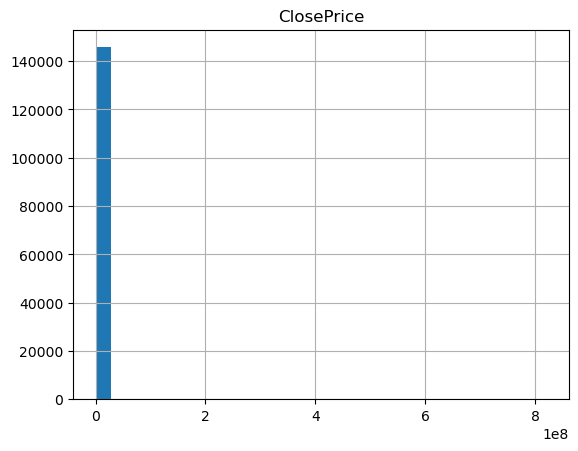

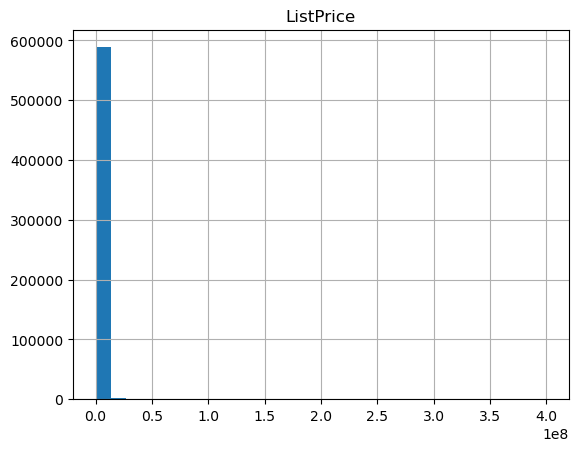

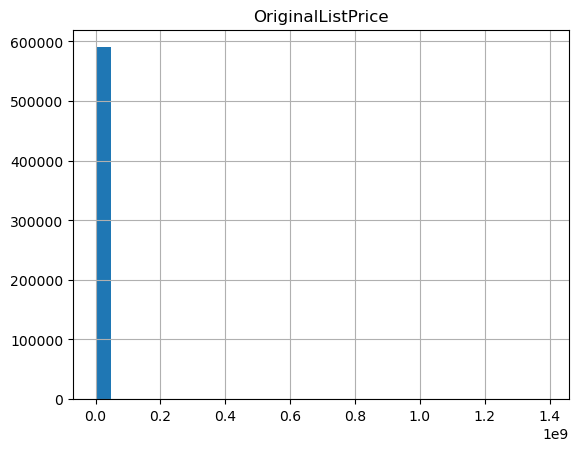

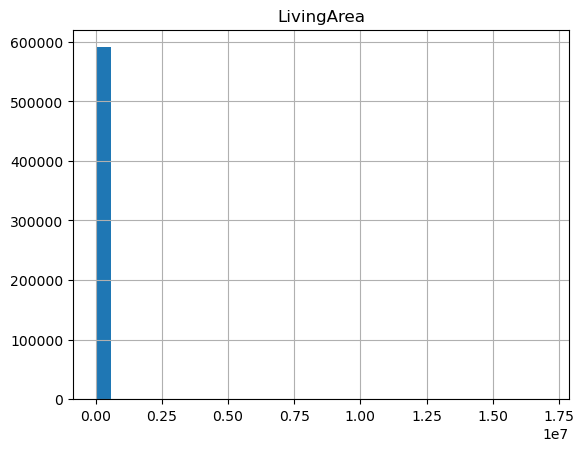

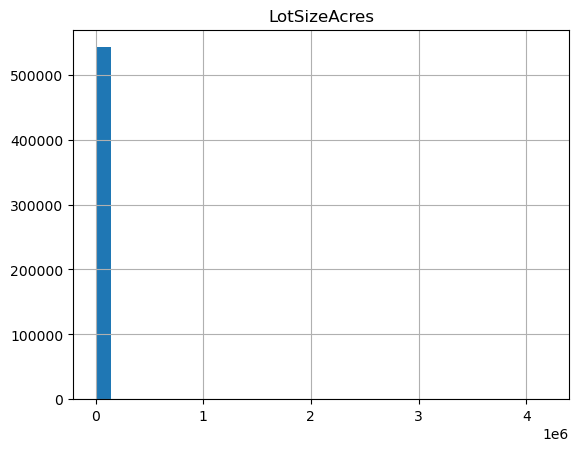

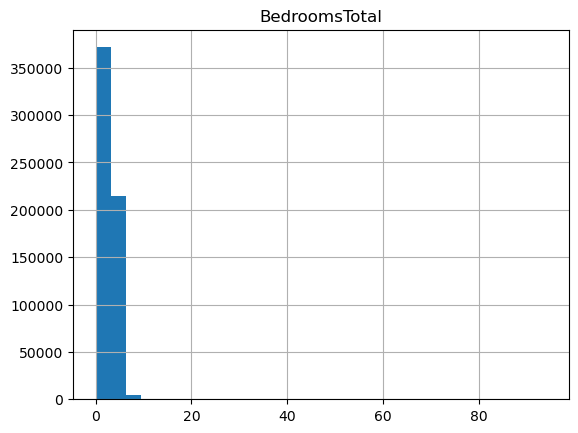

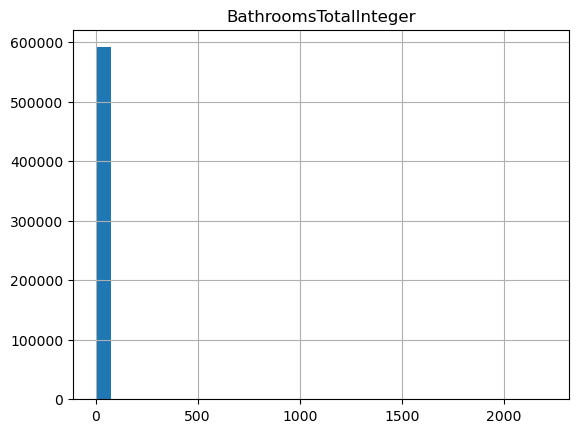

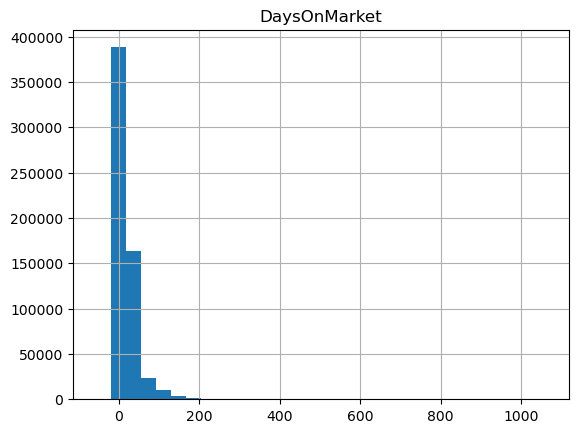

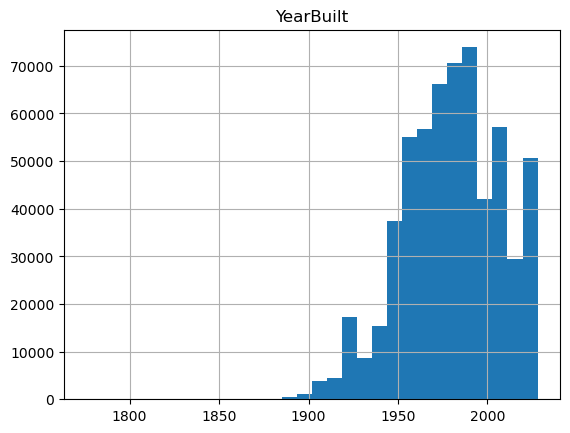

In [27]:
#Historgram numeric distribution for key numeric fields for sold
for column in numeric_cols_sold:
    final_sold[column].hist(bins=30)
    plt.title(column)
    plt.show()

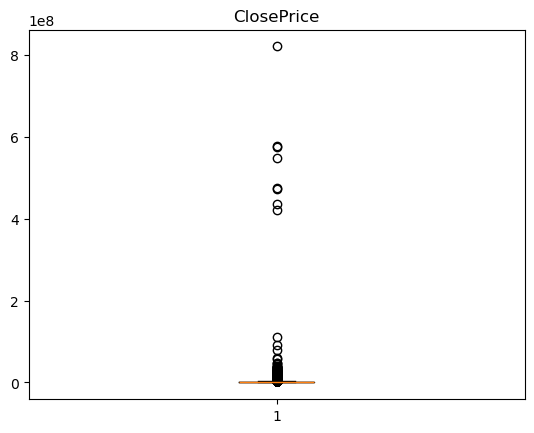

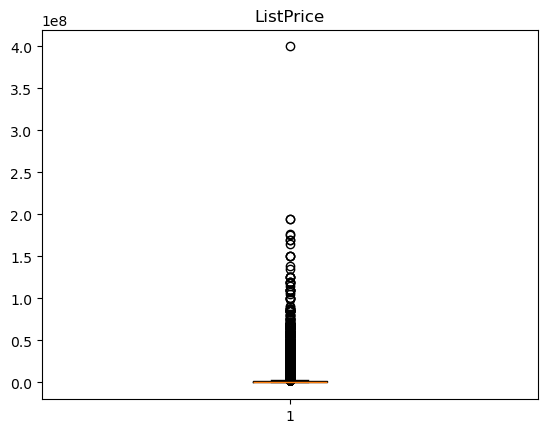

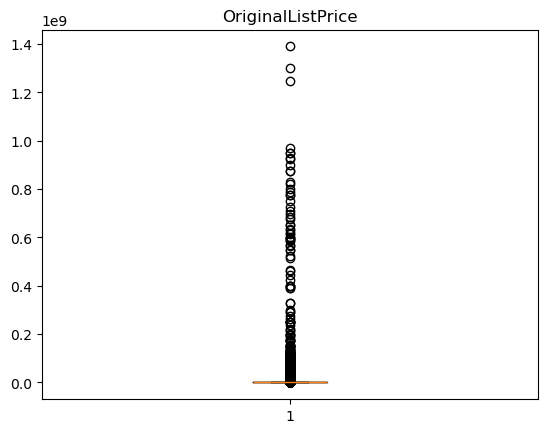

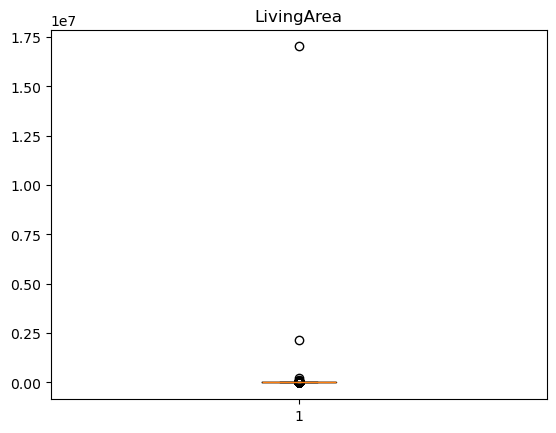

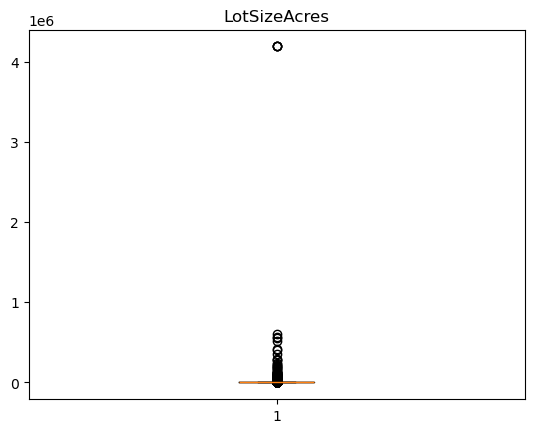

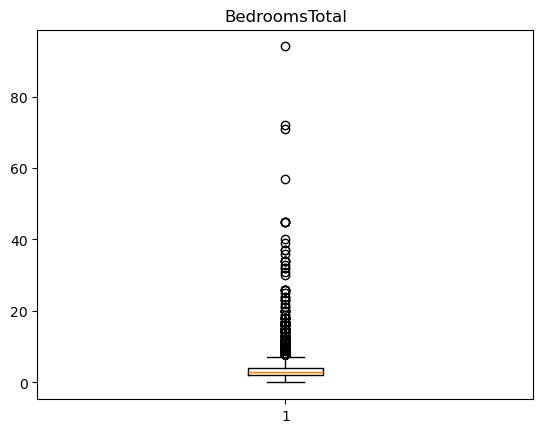

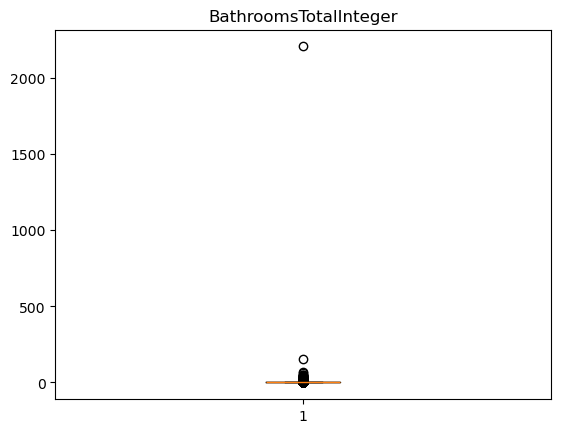

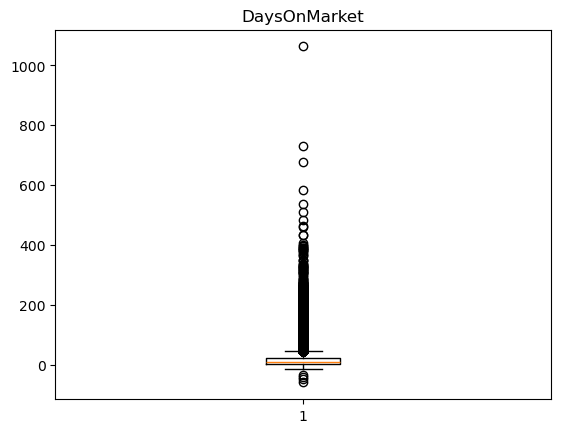

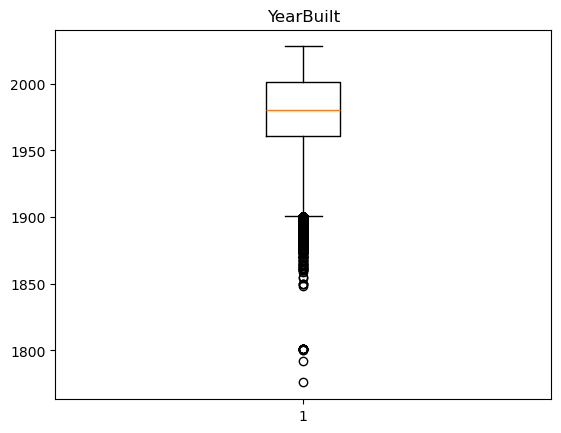

In [28]:
#Boxplot numeric distribution for key numeric fields for sold
for column in numeric_cols_sold:
    plt.boxplot(final_sold[column].dropna())
    plt.title(column)
    plt.show()

## Listings Dataset

### Dataset Understanding

In [29]:
#first five rows of listing dataset
list.head()

,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,...,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,BuyerOfficeName.1,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,UnparsedAddress.1
0,1340000.0,1074973329,haleh360@Gmail.com,NaN,NaN,Haleh,Dowlatshahi,34.052207,-118.408445,2220 Avenue Of The Stars 2704,...,NaN,False,NaN,NaN,90067,NaN,2105.00,177861.0,NaN,2220 Avenue Of The Stars 2704
1,2500000.0,1074954552,Reneechen@yourhomesoldguaranteed.com,NaN,NaN,Renee,Chen,33.496363,-117.691677,16 Palisades,...,0.0,False,3.0,Capistrano Unified,92677,NaN,254.00,5300.0,NaN,16 Palisades
2,3150000.0,1074936537,anader@dppre.com,NaN,NaN,Margaret,Nader,34.119345,-118.111254,1615 Waverly Road,...,NaN,NaN,2.0,NaN,91108,NaN,NaN,9404.0,NaN,1615 Waverly Road
3,3090000.0,1074917818,QIANYU0607@GMAIL.COM,NaN,NaN,QIANYU,GUAN,33.984057,-117.802819,2250 Indian Creek Road,...,1.0,False,4.0,Walnut Valley Unified,91765,NaN,295.95,58232.0,NaN,2250 Indian Creek Road
4,12725000.0,1074143166,jeff.williams@pacificsir.com,NaN,NaN,Jeff,Williams,33.607583,-117.887743,317 E. Bayfront,...,3.0,False,2.0,Newport Mesa Unified,92662,NaN,0.00,2250.0,NaN,317 E. Bayfront


In [30]:
#591,465 rows and 84 columns for listings
list.shape

(591465, 84)

In [31]:
#all the names of the columns in listings
list.columns

Index(['OriginalListPrice', 'ListingKey', 'ListAgentEmail', 'CloseDate',
       'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName', 'Latitude',
       'Longitude', 'UnparsedAddress', 'PropertyType', 'LivingArea',
       'ListPrice', 'DaysOnMarket', 'ListOfficeName', 'BuyerOfficeName',
       'CoListOfficeName', 'ListAgentFullName', 'CoListAgentFirstName',
       'CoListAgentLastName', 'BuyerAgentMlsId', 'BuyerAgentFirstName',
       'BuyerAgentLastName', 'FireplacesTotal', 'AssociationFeeFrequency',
       'AboveGradeFinishedArea', 'ListingKeyNumeric', 'MLSAreaMajor',
       'TaxAnnualAmount', 'CountyOrParish', 'PropertyType.1', 'MlsStatus',
       'ElementarySchool', 'ListAgentFirstName.1', 'AttachedGarageYN',
       'ParkingTotal', 'BuilderName', 'PropertySubType', 'LotSizeAcres',
       'SubdivisionName', 'BuyerOfficeAOR', 'YearBuilt', 'DaysOnMarket.1',
       'BuyerAgencyCompensationType', 'StreetNumberNumeric', 'LivingArea.1',
       'ListingId', 'BathroomsTotalInteger', 'Cit

In [32]:
#datatypes for all the columns in listings
list.dtypes

OriginalListPrice               float64
ListingKey                        int64
ListAgentEmail                   object
CloseDate                        object
ClosePrice                      float64
                                 ...   
BuyerOfficeName.1                object
AssociationFee                  float64
LotSizeSquareFeet               float64
MiddleOrJuniorSchoolDistrict    float64
UnparsedAddress.1                object
Length: 84, dtype: object

In [33]:
#identify property types in list
list["PropertyType"].value_counts()

PropertyType
Residential    591465
Name: count, dtype: int64

In [34]:
#Checking propety type categories in list
list["PropertyType"].unique()

array(['Residential'], dtype=object)

In [35]:
#filter to just residential property types and identify the shape of the new list dataset
list_new = list[list["PropertyType"]=="Residential"]
list_new.shape

(591465, 84)

### Missing Value Analysis

In [36]:
#identify percentage of missing data in the columns of list
list_missing_percent = list_new.isnull().mean()*100
list_missing_percent

OriginalListPrice                 0.142358
ListingKey                        0.000000
ListAgentEmail                    4.307947
CloseDate                        71.475404
ClosePrice                       75.351881
                                   ...    
BuyerOfficeName.1                73.110835
AssociationFee                   24.109288
LotSizeSquareFeet                 8.087883
MiddleOrJuniorSchoolDistrict    100.000000
UnparsedAddress.1                 0.143711
Length: 84, dtype: float64

In [37]:
#identify which columns in list are over 90% missing data
list_missing_percent[list_missing_percent>90].index

Index(['FireplacesTotal', 'AboveGradeFinishedArea', 'TaxAnnualAmount',
       'BuilderName', 'TaxYear', 'BuildingAreaTotal',
       'ElementarySchoolDistrict', 'CoBuyerAgentFirstName',
       'BelowGradeFinishedArea', 'BusinessType', 'CoveredSpaces',
       'LotSizeDimensions', 'MiddleOrJuniorSchoolDistrict'],
      dtype='object')

In [38]:
#drop irrelevants columns that have over 90% missing data in list
drop_list_cols = ['FireplacesTotal', 'AboveGradeFinishedArea', 'TaxAnnualAmount',
       'BuilderName', 'TaxYear', 'BuildingAreaTotal',
       'ElementarySchoolDistrict', 'CoBuyerAgentFirstName',
       'BelowGradeFinishedArea', 'BusinessType', 'CoveredSpaces',
       'LotSizeDimensions', 'MiddleOrJuniorSchoolDistrict']
final_listings = list_new.drop(columns=drop_list_cols)
final_listings.head()

,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,...,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,BuyerOfficeName.1,AssociationFee,LotSizeSquareFeet,UnparsedAddress.1
0,1340000.0,1074973329,haleh360@Gmail.com,NaN,NaN,Haleh,Dowlatshahi,34.052207,-118.408445,2220 Avenue Of The Stars 2704,...,177861.0,NaN,False,NaN,NaN,90067,NaN,2105.00,177861.0,2220 Avenue Of The Stars 2704
1,2500000.0,1074954552,Reneechen@yourhomesoldguaranteed.com,NaN,NaN,Renee,Chen,33.496363,-117.691677,16 Palisades,...,5300.0,0.0,False,3.0,Capistrano Unified,92677,NaN,254.00,5300.0,16 Palisades
2,3150000.0,1074936537,anader@dppre.com,NaN,NaN,Margaret,Nader,34.119345,-118.111254,1615 Waverly Road,...,9404.0,NaN,NaN,2.0,NaN,91108,NaN,NaN,9404.0,1615 Waverly Road
3,3090000.0,1074917818,QIANYU0607@GMAIL.COM,NaN,NaN,QIANYU,GUAN,33.984057,-117.802819,2250 Indian Creek Road,...,58232.0,1.0,False,4.0,Walnut Valley Unified,91765,NaN,295.95,58232.0,2250 Indian Creek Road
4,12725000.0,1074143166,jeff.williams@pacificsir.com,NaN,NaN,Jeff,Williams,33.607583,-117.887743,317 E. Bayfront,...,2250.0,3.0,False,2.0,Newport Mesa Unified,92662,NaN,0.00,2250.0,317 E. Bayfront


### Numeric Distribution

In [39]:
#Percentile summaries for the following columns in list
numeric_cols_list = ["ClosePrice", "ListPrice", "OriginalListPrice", "LivingArea", "LotSizeAcres", "BedroomsTotal", "BathroomsTotalInteger", "DaysOnMarket", "YearBuilt"]
final_listings[numeric_cols_list].describe(percentiles=[0.10,0.25,0.50,0.75,0.90])

,ClosePrice,ListPrice,OriginalListPrice,LivingArea,LotSizeAcres,BedroomsTotal,BathroomsTotalInteger,DaysOnMarket,YearBuilt
count,1.457850e+05,5.914650e+05,5.906230e+05,5.908630e+05,5.429020e+05,591303.000000,591408.000000,591465.000000,590448.000000
mean,1.209678e+06,1.318468e+06,1.402482e+06,1.980143e+03,6.143188e+01,3.226742,2.630208,18.682595,1979.686531
std,4.296045e+06,2.411247e+06,7.313720e+06,2.235101e+04,1.160067e+04,1.188312,3.136176,25.889653,27.026516
min,5.250000e+02,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,-58.000000,1776.000000
10%,4.300000e+05,4.199000e+05,4.200000e+05,9.630000e+02,6.000000e-02,2.000000,1.000000,1.000000,1947.000000
25%,6.000000e+05,5.805320e+05,5.850000e+05,1.248000e+03,1.200000e-01,2.000000,2.000000,5.000000,1961.000000
50%,8.580000e+05,8.488880e+05,8.490000e+05,1.672000e+03,1.700000e-01,3.000000,2.000000,11.000000,1980.000000
75%,1.352000e+06,1.385000e+06,1.395000e+06,2.302000e+03,3.161750e-01,4.000000,3.000000,22.000000,2001.000000
90%,2.150000e+06,2.350000e+06,2.385000e+06,3.155000e+03,1.359300e+00,5.000000,4.000000,41.000000,2018.000000
max,8.200000e+08,4.000000e+08,1.390000e+09,1.702132e+07,4.187292e+06,94.000000,2208.000000,1063.000000,2028.000000


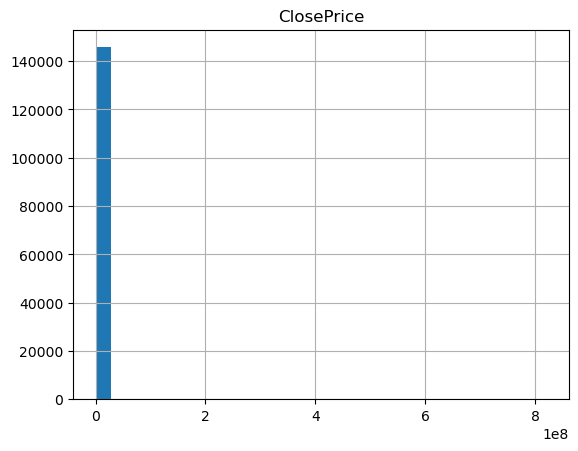

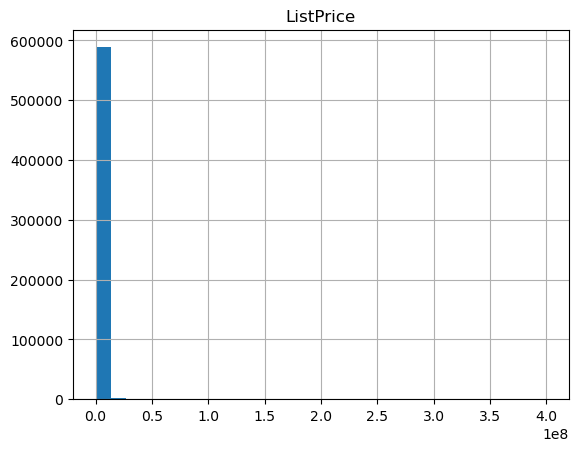

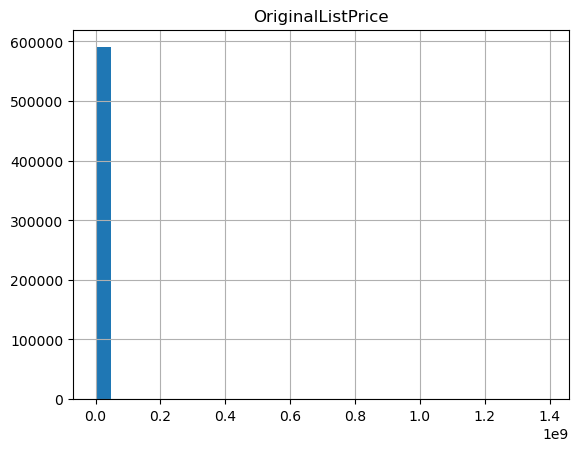

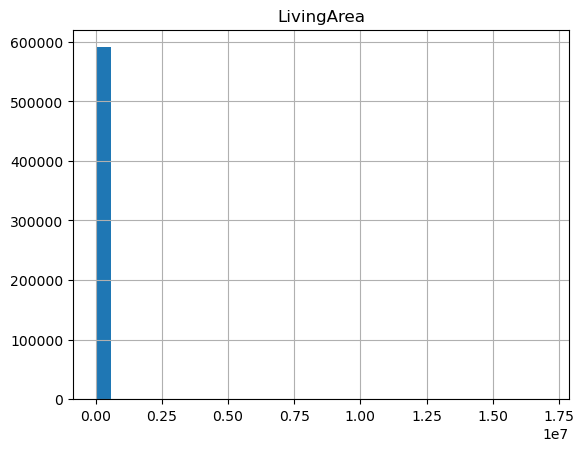

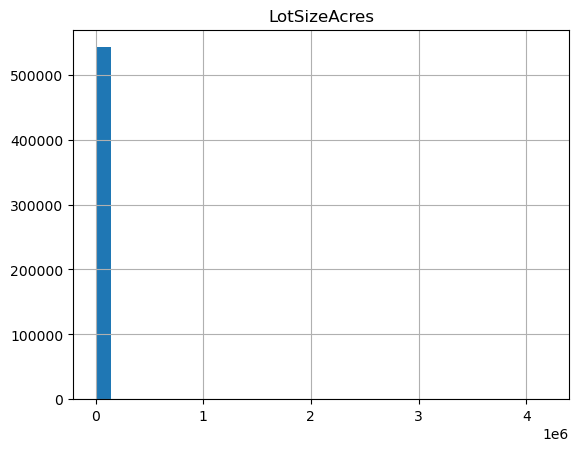

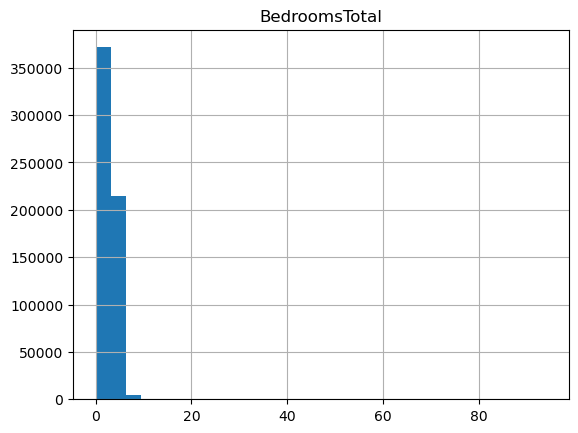

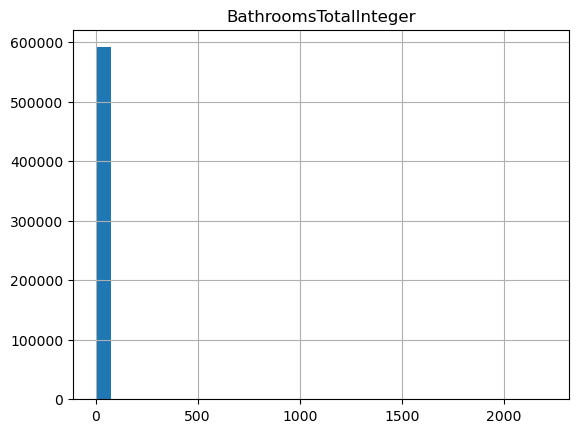

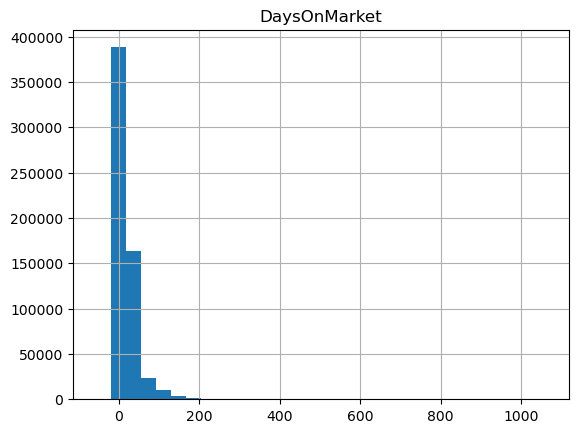

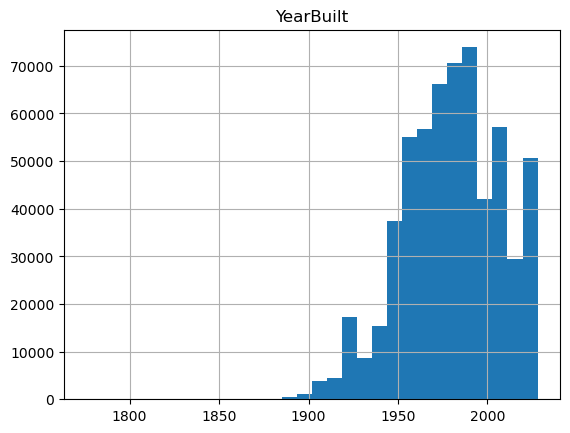

In [40]:
#Historgram numeric distribution for key numeric fields for list
for column in numeric_cols_list:
    final_listings[column].hist(bins=30)
    plt.title(column)
    plt.show()

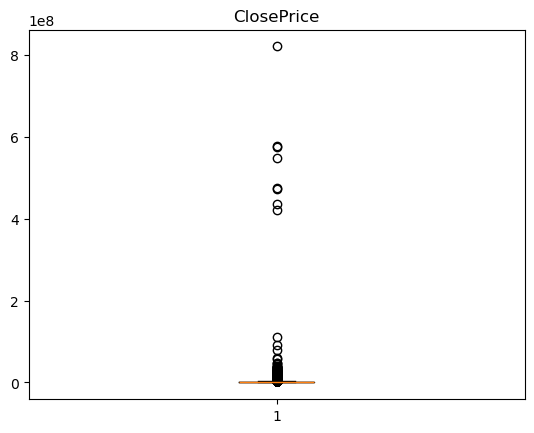

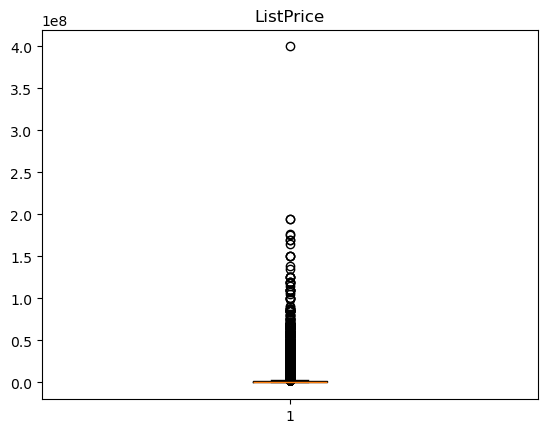

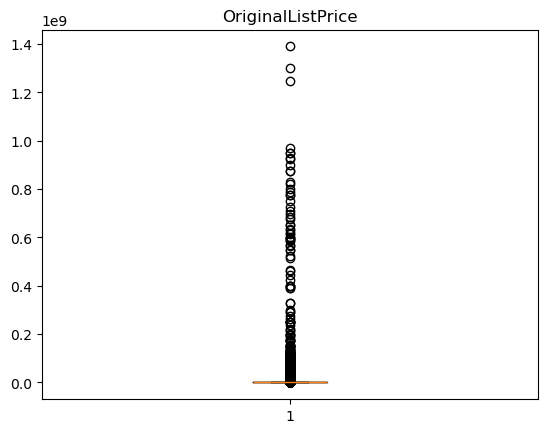

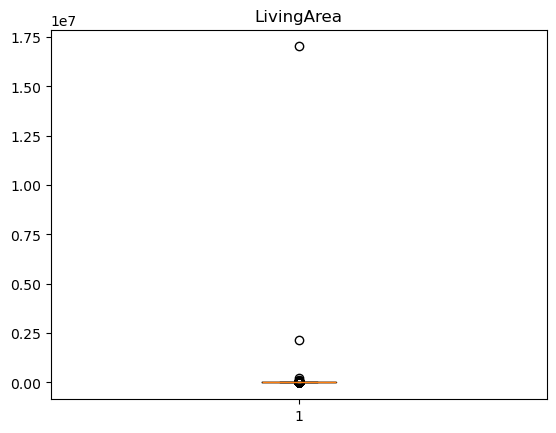

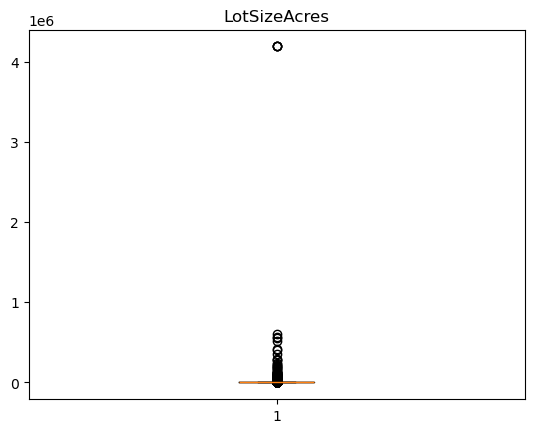

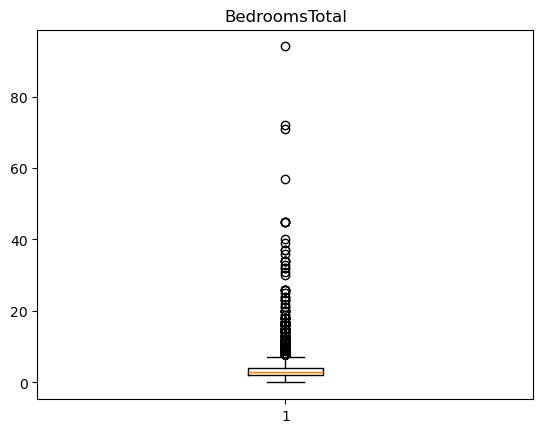

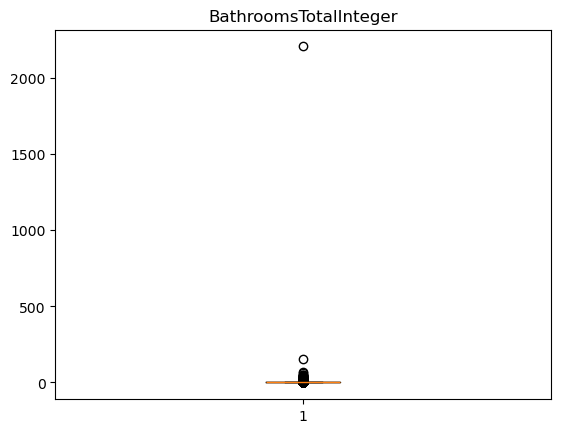

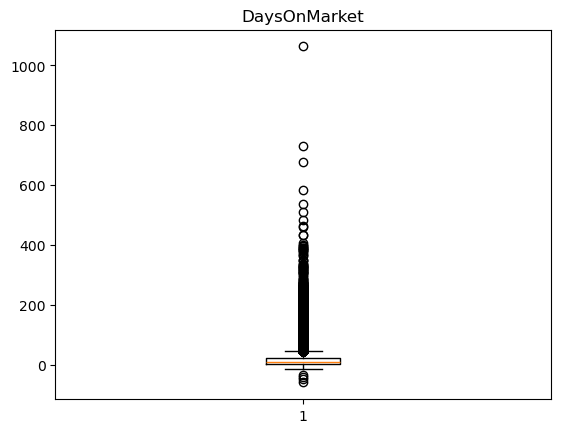

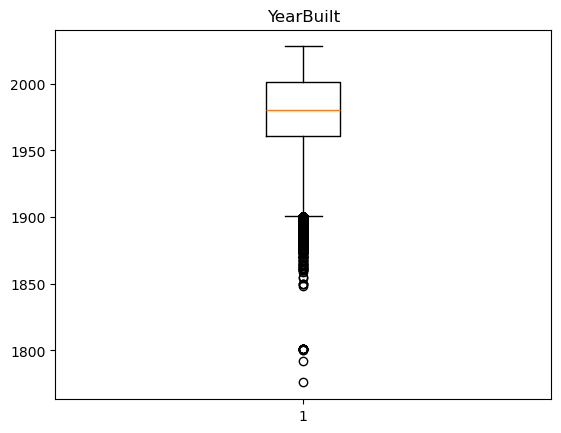

In [41]:
#Boxplot numeric distribution for key numeric fields for listings
for column in numeric_cols_list:
    plt.boxplot(final_listings[column].dropna())
    plt.title(column)
    plt.show()

## Suggested Intern Questions EDA

In [42]:
#Mean and Median of Close Prices
print(sold["ClosePrice"].mean())
print(sold["ClosePrice"].median())

1209677.639265494
858000.0


<Axes: >

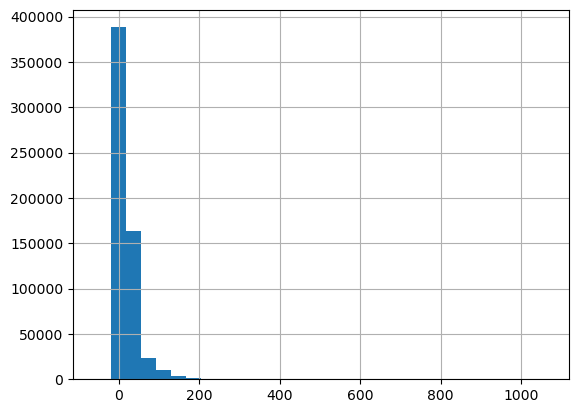

In [43]:
#Days on Market Distribution
sold["DaysOnMarket"].hist(bins=30)

In [44]:
#Sold above or below list price
above = sold["ClosePrice"] > sold["ListPrice"]
above.value_counts(normalize=True)*100

False    89.148132
True     10.851868
Name: proportion, dtype: float64

In [45]:
#Date Consistency
sold[sold["CloseDate"]<sold["ListingContractDate"]]

,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,...,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,BuyerOfficeName.1,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,UnparsedAddress.1
1406,2195000.0,1059827487,RE@juliefeld.com,2024-01-30,2160000.0,Julie,Feld,NaN,NaN,17555 Luna de Miel,...,NaN,False,3.0,NaN,92067,Pacific Sotheby's International Realty,1400.00,NaN,NaN,17555 Luna de Miel
4140,2705000.0,1059357897,lindsay@thedunlapteam.com,2024-01-25,2705000.0,Lindsay,Dunlap,NaN,NaN,13913 Recuerdo Drive,...,NaN,False,2.0,NaN,92014,PURE San Diego,NaN,NaN,NaN,13913 Recuerdo Drive
16407,1600000.0,1054052014,joseph@arendsengroup.com,2024-01-01,1600000.0,Joseph,Arendsen,NaN,NaN,506 N Myers St,...,NaN,False,2.0,NaN,92054,Willis Allen Real Estate,695.00,13567.0,NaN,506 N Myers St
41873,1595000.0,1063548623,jamie@gregcummings.com,2024-03-20,1650000.0,Jamie,Lindsay,NaN,NaN,1421 Everview Rd,...,NaN,False,0.0,NaN,92110,Compass,NaN,NaN,NaN,1421 Everview Rd
73360,1075000.0,1065738283,JulieBradenHomes@gmail.com,2024-03-29,1075000.0,Julie,Braden,34.168366,-118.970132,4445 Camino De Las Estrellas,...,NaN,NaN,3.0,NaN,91320,Coldwell Banker Realty,135.00,2615.0,NaN,4445 Camino De Las Estrellas
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
579165,3000000.0,1168402079,NaN,2026-05-06,3000000.0,Rachael,Kaiser,32.816909,-117.268462,5734 Waverly Ave,...,NaN,False,2.0,NaN,92037,Keller Williams La Jolla,NaN,NaN,NaN,5734 Waverly Ave
581723,2395000.0,1160125559,NaN,2026-04-22,2340000.0,Alfonso,Aldrete,32.811858,-117.268302,5460 La Jolla Blvd G202,...,NaN,False,2.0,NaN,92037,"eXp Realty of California, Inc.",784.00,NaN,NaN,5460 La Jolla Blvd G202
586185,849999.0,1159691054,NaN,2026-05-07,850000.0,Kristine,Kappel,32.604412,-117.070988,426 Anita June Ct,...,NaN,False,2.0,NaN,91911,Compass,NaN,NaN,NaN,426 Anita June Ct
587821,4300000.0,1159568360,NaN,2026-04-08,4300000.0,Marilyn,Comiskey,32.737209,-117.160625,2855 5th Ave 1104,...,NaN,False,2.0,NaN,92103,Compass,2307.98,NaN,NaN,2855 5th Ave 1104


In [46]:
#Highest Median Price by County
sold.groupby("CountyOrParish")["ClosePrice"].median().sort_values(ascending=False)

CountyOrParish
San Mateo          1760500.0
Santa Clara        1640000.0
Marin              1337000.0
San Francisco      1250000.0
Santa Cruz         1218000.0
                     ...    
Sierra              255000.0
Alpine                   NaN
Del Norte                NaN
Foreign Country          NaN
Humboldt                 NaN
Name: ClosePrice, Length: 63, dtype: float64

## Saving updated datasets as CSV files

In [47]:
final_listings.to_csv("ResidentialListingsFINAL.csv",index=False)
final_sold.to_csv("ResidentialSoldFINAL.csv",index=False)